<a href="https://colab.research.google.com/github/anumit2004/Graph-Attention/blob/main/Single_Head_using_Pytorch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Single Head Attention using Pytorch .

In [1]:
!pip install torch_geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 45.2 MB/s eta 0:00:00


In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
from torch_geometric.datasets import Planetoid

In [3]:
def _sparse_softmax(e: torch.tensor , dst : torch.tensor , N : int ):
  """
  e: Attention scores  has dimension (E,) E is the number of nodes .
  dst : Destination nodes of the edges has dimension (E,) E is the number of nodes .
  N: Number of nodes
  """
  e_max = torch.full((N,),float('-inf')) #[N,]
  e_max.scatter_reduce_(0 , dst , e , reduce = 'amax', include_self = True)
  e = torch.exp(e - e_max[dst])

  denom = torch.zeros(N)
  denom.scatter_add_(0,dst,e)

  return e/(denom[dst] + 1e-16)

## Complete FLow with Mathametical Explanation of **Single-Head GAT*:

For $node (i)$ :

$x_i \xrightarrow{W} h_i \quad (h_i = Wx_i)$

For every $neighbor (j)$ :

$[h_i || h_j] \xrightarrow{a^T} e_{ij} \quad (e_{ij} = \text{LeakyReLU}(a^T[h_i || h_j]))$

Normalize :

$e_{ij} \xrightarrow{Softmax} \alpha_{ij} \quad (\alpha_{ij} = \frac{\exp(e_{ij})}{\sum_{k \in \mathcal{N}_i} \exp(e_{ik})})$

Aggregate :

$h_i' = \sum_{j \in \mathcal{N}_i} \alpha_{ij} h_j$

In [4]:
class GAT_Single_Head(nn.Module):
  def __init__(self, in_features: int , out_features: int , dropout:float = 0.2 , alpha:float = 0.2):
    super().__init__()
    self.in_features = in_features
    self.out_features = out_features
    self.dropout = dropout
    self.alpha = alpha

    self.W = nn.Linear(in_features , out_features)
    self.a_src = nn.Parameter(torch.empty(out_features,1))
    self.a_dst = nn.Parameter (torch.empty(out_features,1))

    self.leakyRELU = nn.LeakyReLU(self.alpha)
    self._init_weights()

  def _init_weights(self):
    nn.init.xavier_uniform(self.W.weight)
    nn.init.xavier_uniform(self.a_src)
    nn.init.xavier_uniform(self.a_dst)

  def forward(self, x: torch.tensor , edge_index: torch.tensor ):
    h = self.W(x) #[N , out_features]
    h = F.dropout(h, self.dropout, training=self.training)
    src , dst = edge_index[0] , edge_index[1]  # each [E,]

    e = self.leakyRELU((h @ self.a_src)[src] + (h @ self.a_dst)[dst]) #[E,]

    alpha = _sparse_softmax(e.squeeze(-1),dst,x.shape[0]) #[E,]
    alpha = F.dropout(alpha, self.dropout, training=self.training)

    out = torch.zeros_like(h)
    out.scatter_add_(0, dst.unsqueeze(-1).expand(-1 , self.out_features) , alpha.unsqueeze(-1) * h[src])
    return F.elu(out)



In [5]:
def execution():
  print("\n" + "="*60)
  print("Single-Head GAT Layer (PyTorch)")
  print("="*60)
  N, F_in, F_out = 5, 8, 4
  x = torch.randn(N, F_in)
  # Simple path graph: 0→1→2→3→4 with self-loops
  edges = [[0,1,2,3,4,0,1,2,3,4],[0,1,2,3,4,1,2,3,4,0]]
  edge_index = torch.tensor(edges, dtype=torch.long)

  layer = GAT_Single_Head(F_in, F_out)
  out = layer(x, edge_index)
  print(f"Input  : {x.shape}")
  print(f"Output : {out.shape}")
  print(f"Sample output (node 0): {out[0].detach().numpy().round(4)}")
  print(f"Sample output (node 1): {out[1].detach().numpy().round(4)}")
  print(f"Sample output (node 2): {out[2].detach().numpy().round(4)}")
  print(f"Sample output (node 3): {out[3].detach().numpy().round(4)}")
  print(f"Sample output (node 4): {out[4].detach().numpy().round(4)}")
  print("\n" + "="*60)

In [6]:
execution()


Single-Head GAT Layer (PyTorch)
Input  : torch.Size([5, 8])
Output : torch.Size([5, 4])
Sample output (node 0): [ 0.064  -0.8395 -0.8718 -0.1174]
Sample output (node 1): [-0.7158 -0.4551 -0.8092 -0.418 ]
Sample output (node 2): [-0.5486 -0.9312 -0.3213  0.0823]
Sample output (node 3): [-0.6138  1.1357  1.0462  0.    ]
Sample output (node 4): [-0.5413 -0.6098 -0.7246  0.7358]



/tmp/ipykernel_714/2054307696.py:17: FutureWarning: `nn.init.xavier_uniform` is now deprecated in favor of `nn.init.xavier_uniform_`.
  nn.init.xavier_uniform(self.W.weight)
/tmp/ipykernel_714/2054307696.py:18: FutureWarning: `nn.init.xavier_uniform` is now deprecated in favor of `nn.init.xavier_uniform_`.
  nn.init.xavier_uniform(self.a_src)
/tmp/ipykernel_714/2054307696.py:19: FutureWarning: `nn.init.xavier_uniform` is now deprecated in favor of `nn.init.xavier_uniform_`.
  nn.init.xavier_uniform(self.a_dst)


## Multi-layer GAT Classifier (Single Head)

This section defines a `SingleHeadGAT_Classifier` which stacks two `GAT_Single_Head` layers to create a simple graph neural network for classification tasks.

- The first `GAT_Single_Head` layer transforms the input features into a hidden representation.
- The second `GAT_Single_Head` layer takes this hidden representation and outputs scores for each class.
- Dropout is applied between layers for regularization.
- Finally, `F.log_softmax` is used to convert the output scores into log-probabilities suitable for negative log-likelihood loss (NLLLoss).

In [7]:
class SingleHeadGAT_Classifier(nn.Module):
    def __init__(self, in_features: int, hidden_features: int, num_classes: int, dropout: float = 0.6, alpha: float = 0.2):
        super().__init__()
        self.dropout = dropout

        # Layer 1: Input to Hidden
        self.gat1 = GAT_Single_Head(in_features, hidden_features, dropout=dropout, alpha=alpha)
        # Layer 2: Hidden to Output Classes
        self.gat2 = GAT_Single_Head(hidden_features, num_classes, dropout=dropout, alpha=alpha)

    def forward(self, x: torch.Tensor, edge_index: torch.Tensor):
        # First GAT layer with dropout
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.gat1(x, edge_index)

        # Second GAT layer with dropout
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.gat2(x, edge_index)

        # Log-softmax for classification probabilities
        return F.log_softmax(x, dim=1)

# Training over the CORA , CITESEER , PUBMED dataset using **Multi-Layer Single Head GAT**  

In [12]:
def train_and_evaluate_single_head(dataset_name: str, epochs: int = 200, lr: float = 0.005, weight_decay: float = 5e-4):
    print("\n" + "="*60)
    print(f"Training Single-Head GAT on {dataset_name} Dataset")
    print("="*60)

    # 1. Load Dataset
    dataset = Planetoid(root=f'/tmp/{dataset_name}', name=dataset_name)
    data = dataset[0]

    # 2. Initialize Model and Optimizer
    model = SingleHeadGAT_Classifier(
        in_features=dataset.num_node_features,
        hidden_features=8,
        num_classes=dataset.num_classes,
        dropout=0.6
    )

    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    criterion = nn.NLLLoss()

    # Metrics storage for plotting
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

    # 3. Training Loop
    for epoch in range(epochs):
        # --- TRAINING PHASE ---
        model.train()
        optimizer.zero_grad()

        out_train = model(data.x, data.edge_index)
        loss = criterion(out_train[data.train_mask], data.y[data.train_mask])

        loss.backward()
        optimizer.step()

        # --- EVALUATION PHASE ---
        model.eval()
        with torch.no_grad():
            # FRESH forward pass without dropout for accurate metrics
            out_eval = model(data.x, data.edge_index)
            pred = out_eval.argmax(dim=1)

            # Calculate true training accuracy (without dropout noise)
            train_correct = pred[data.train_mask] == data.y[data.train_mask]
            train_acc = int(train_correct.sum()) / int(data.train_mask.sum())

            # Calculate validation loss and accuracy
            val_loss = criterion(out_eval[data.val_mask], data.y[data.val_mask])
            val_correct = pred[data.val_mask] == data.y[data.val_mask]
            val_acc = int(val_correct.sum()) / int(data.val_mask.sum())

        # Store metrics
        history['train_loss'].append(loss.item())
        history['val_loss'].append(val_loss.item())
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)

        if (epoch + 1) % 20 == 0:
            print(f'Epoch {epoch+1:03d} | Train Loss: {loss:.4f} | Train Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}')

    # 5. Final Testing
    model.eval()
    with torch.no_grad():
        out_test = model(data.x, data.edge_index)
        pred_test = out_test.argmax(dim=1)
        test_correct = pred_test[data.test_mask] == data.y[data.test_mask]
        test_acc = int(test_correct.sum()) / int(data.test_mask.sum())

    print("-" * 60)
    print(f"Final Test Accuracy on {dataset_name}: {test_acc:.4f}")
    print("-" * 60)

    # 6. Plotting
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'Single-Head GAT Training Dynamics: {dataset_name}', fontsize=16)

    ax1.plot(history['train_loss'], label='Train Loss', color='blue')
    ax1.plot(history['val_loss'], label='Val Loss', color='orange')
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel('Loss (NLL)')
    ax1.legend()
    ax1.grid(True, linestyle='--', alpha=0.6)

    ax2.plot(history['train_acc'], label='Train Accuracy', color='green')
    ax2.plot(history['val_acc'], label='Val Accuracy', color='red')
    ax2.set_xlabel('Epochs')
    ax2.set_ylabel('Accuracy')
    ax2.legend()
    ax2.grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.show()


Training Single-Head GAT on Cora Dataset


/tmp/ipykernel_714/2054307696.py:17: FutureWarning: `nn.init.xavier_uniform` is now deprecated in favor of `nn.init.xavier_uniform_`.
  nn.init.xavier_uniform(self.W.weight)
/tmp/ipykernel_714/2054307696.py:18: FutureWarning: `nn.init.xavier_uniform` is now deprecated in favor of `nn.init.xavier_uniform_`.
  nn.init.xavier_uniform(self.a_src)
/tmp/ipykernel_714/2054307696.py:19: FutureWarning: `nn.init.xavier_uniform` is now deprecated in favor of `nn.init.xavier_uniform_`.
  nn.init.xavier_uniform(self.a_dst)


Epoch 020 | Train Loss: 2.0315 | Train Acc: 0.3357 | Val Loss: 1.9653 | Val Acc: 0.1520
Epoch 040 | Train Loss: 2.0240 | Train Acc: 0.4286 | Val Loss: 1.9058 | Val Acc: 0.2440
Epoch 060 | Train Loss: 1.9354 | Train Acc: 0.5286 | Val Loss: 1.8780 | Val Acc: 0.3000
Epoch 080 | Train Loss: 2.0507 | Train Acc: 0.6071 | Val Loss: 1.8475 | Val Acc: 0.4060
Epoch 100 | Train Loss: 2.0721 | Train Acc: 0.6500 | Val Loss: 1.8235 | Val Acc: 0.4440
Epoch 120 | Train Loss: 1.9369 | Train Acc: 0.6571 | Val Loss: 1.8020 | Val Acc: 0.4640
Epoch 140 | Train Loss: 1.7988 | Train Acc: 0.6143 | Val Loss: 1.8027 | Val Acc: 0.4580
Epoch 160 | Train Loss: 1.8982 | Train Acc: 0.6643 | Val Loss: 1.7848 | Val Acc: 0.4940
Epoch 180 | Train Loss: 1.9147 | Train Acc: 0.7643 | Val Loss: 1.7573 | Val Acc: 0.6380
Epoch 200 | Train Loss: 1.8583 | Train Acc: 0.8214 | Val Loss: 1.7455 | Val Acc: 0.7040
------------------------------------------------------------
Final Test Accuracy on Cora: 0.6730
-----------------------

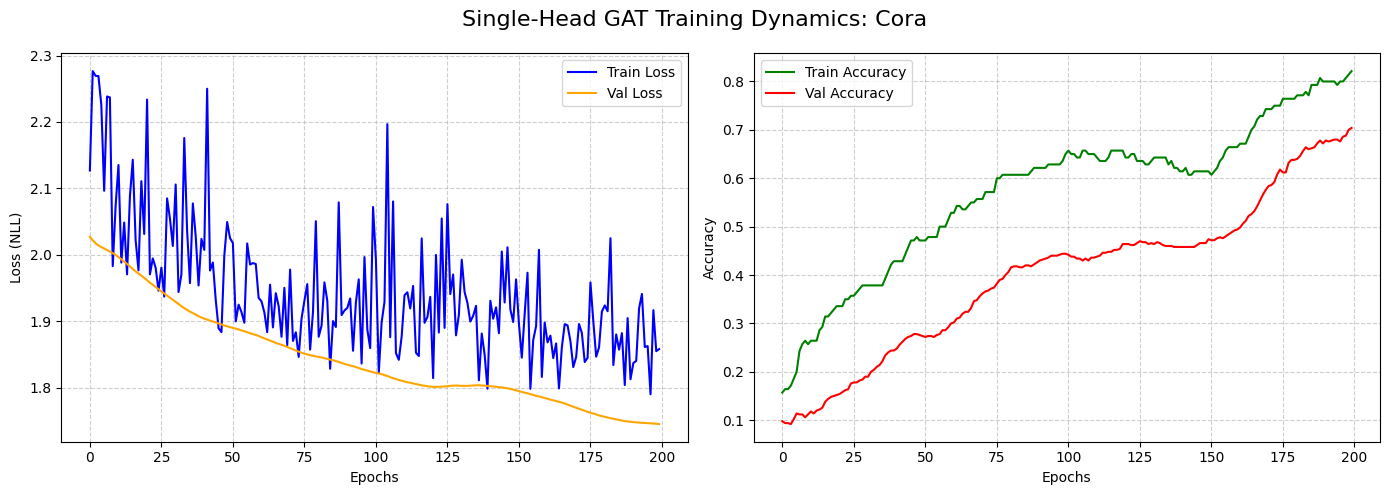


Training Single-Head GAT on CiteSeer Dataset
Epoch 020 | Train Loss: 1.7725 | Train Acc: 0.3500 | Val Loss: 1.7413 | Val Acc: 0.3520
Epoch 040 | Train Loss: 1.7937 | Train Acc: 0.5333 | Val Loss: 1.7223 | Val Acc: 0.3440
Epoch 060 | Train Loss: 1.7392 | Train Acc: 0.5250 | Val Loss: 1.7056 | Val Acc: 0.3660
Epoch 080 | Train Loss: 1.9267 | Train Acc: 0.5000 | Val Loss: 1.7039 | Val Acc: 0.3900
Epoch 100 | Train Loss: 1.7658 | Train Acc: 0.5667 | Val Loss: 1.7155 | Val Acc: 0.3820
Epoch 120 | Train Loss: 1.8327 | Train Acc: 0.6667 | Val Loss: 1.7178 | Val Acc: 0.4020
Epoch 140 | Train Loss: 1.7930 | Train Acc: 0.6917 | Val Loss: 1.7177 | Val Acc: 0.4340
Epoch 160 | Train Loss: 1.7474 | Train Acc: 0.6917 | Val Loss: 1.7289 | Val Acc: 0.4500
Epoch 180 | Train Loss: 1.8407 | Train Acc: 0.6417 | Val Loss: 1.7276 | Val Acc: 0.4180
Epoch 200 | Train Loss: 1.7949 | Train Acc: 0.6500 | Val Loss: 1.7173 | Val Acc: 0.3960
------------------------------------------------------------
Final Test Ac

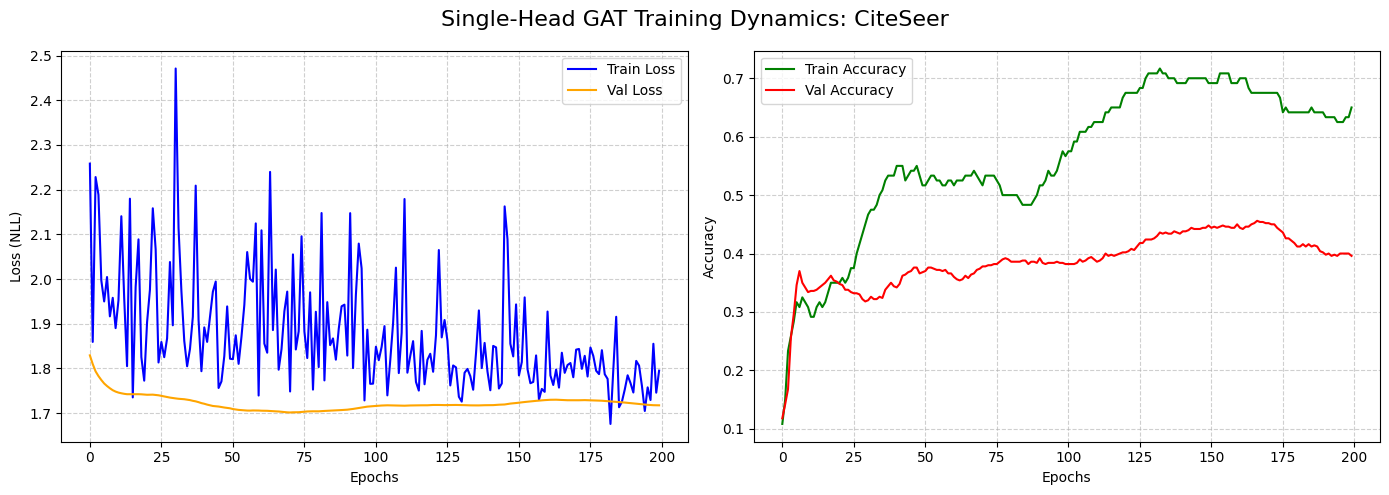


Training Single-Head GAT on PubMed Dataset
Epoch 020 | Train Loss: 1.0924 | Train Acc: 0.6167 | Val Loss: 1.0825 | Val Acc: 0.5220
Epoch 040 | Train Loss: 1.0448 | Train Acc: 0.7833 | Val Loss: 1.0542 | Val Acc: 0.7060
Epoch 060 | Train Loss: 0.9571 | Train Acc: 0.8333 | Val Loss: 1.0274 | Val Acc: 0.7040
Epoch 080 | Train Loss: 1.0346 | Train Acc: 0.9000 | Val Loss: 1.0049 | Val Acc: 0.7180
Epoch 100 | Train Loss: 0.9870 | Train Acc: 0.9167 | Val Loss: 0.9792 | Val Acc: 0.7420
Epoch 120 | Train Loss: 0.9445 | Train Acc: 0.9500 | Val Loss: 0.9536 | Val Acc: 0.7500
Epoch 140 | Train Loss: 0.9214 | Train Acc: 0.9167 | Val Loss: 0.9407 | Val Acc: 0.7580
Epoch 160 | Train Loss: 0.9839 | Train Acc: 0.9333 | Val Loss: 0.9295 | Val Acc: 0.7660
Epoch 180 | Train Loss: 0.8783 | Train Acc: 0.9333 | Val Loss: 0.9020 | Val Acc: 0.7740
Epoch 200 | Train Loss: 0.9523 | Train Acc: 0.9500 | Val Loss: 0.9096 | Val Acc: 0.7500
------------------------------------------------------------
Final Test Accu

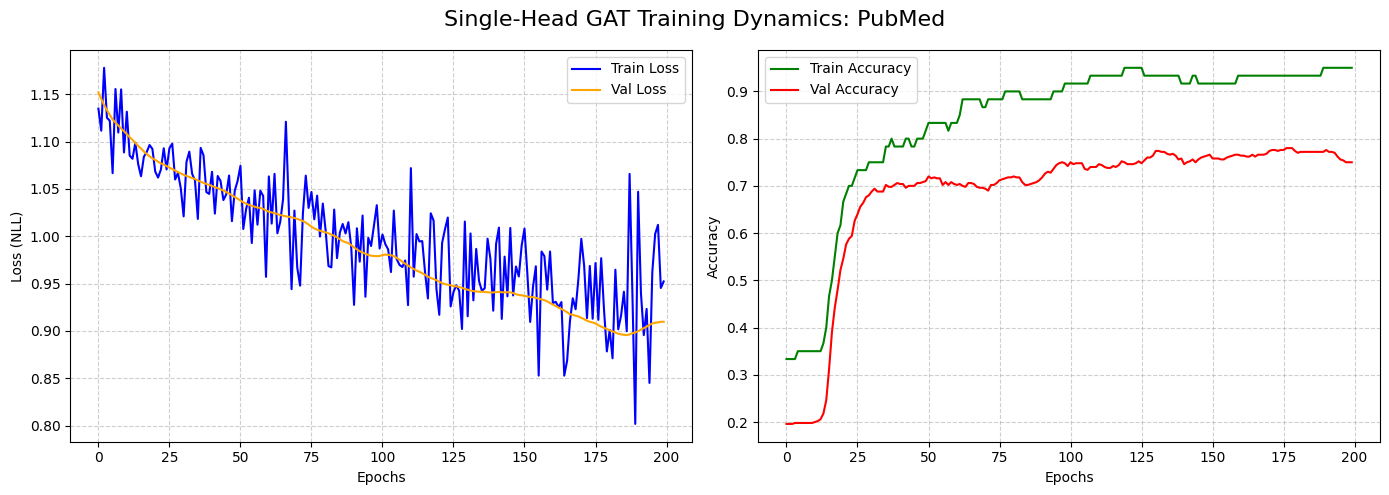

In [13]:
datasets = ['Cora', 'CiteSeer', 'PubMed']

for ds in datasets:
    train_and_evaluate_single_head(ds, epochs=200)